# Numerical Sequence GPT Model Analysis

This notebook provides a comprehensive analysis of the trained numerical sequence GPT model. The model was trained on coordinate data from dataset.txt to learn and generate numerical sequences.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from training_llm import load_model, generate_numerical_sequence, get_device, load_numerical_dataset, normalize_coordinates, numerical_sequence_to_tokens

# Define the same configuration as used in training
num_bins = 200  # Number of bins for quantization
GPT_CONFIG_NUMERICAL = {
    "vocab_size": num_bins + 50,        # vocab size with buffer
    "context_length": 32,            # Context length for coordinate pairs
    "emb_dim": 128,                  # Embedding dimension for numerical data
    "n_heads": 8,                    # Number of attention heads
    "n_layers": 4,                   # Number of layers
    "drop_rate": 0.1,                # Dropout rate
    "qkv_bias": False                # Query-key-value bias
}

## 1. Model Loading and Basic Information

In [2]:
# Load the trained model
try:
    model = load_model("trained_numerical_gpt_model.pth", GPT_CONFIG_NUMERICAL)
    device = get_device()
    model.to(device)
    print(f"OK: Model loaded successfully on {device}")
    print(f"OK: Model configuration: {GPT_CONFIG_NUMERICAL}")
    
    # Show model architecture
    print(f"\nModel architecture:")
    print(f"- Embedding layer: {model.tok_emb}")
    print(f"- Positional embedding: {model.pos_emb}")
    print(f"- Transformer blocks: {len(model.trf_blocks)} layers")
    print(f"- Final norm: {model.final_norm}")
    print(f"- Output head: {model.out_head}")
    
except FileNotFoundError:
    print("ERROR: trained_numerical_gpt_model.pth not found.")
    print("  Please run training_llm.py first to train the model.")
    model = None

Using cpu device.
OK: Model loaded successfully on cpu
OK: Model configuration: {'vocab_size': 250, 'context_length': 32, 'emb_dim': 128, 'n_heads': 8, 'n_layers': 4, 'drop_rate': 0.1, 'qkv_bias': False}

Model architecture:
- Embedding layer: Embedding(250, 128)
- Positional embedding: Embedding(32, 128)
- Transformer blocks: 4 layers
- Final norm: LayerNorm()
- Output head: Linear(in_features=128, out_features=250, bias=False)


## 2. Dataset Analysis

Loading numerical dataset from dataset/dataset.txt
Loaded 9127 sequences from dataset (NaN entries filtered out)
OK: Loaded 9127 sequences from dataset.txt
OK: After filtering NaN values: 9127 sequences
OK: Average sequence length: 39.9 tokens
Total tokens in dataset: 364280
Vocabulary coverage (0-249): 178/250 unique tokens used
Token range: 0 to 199


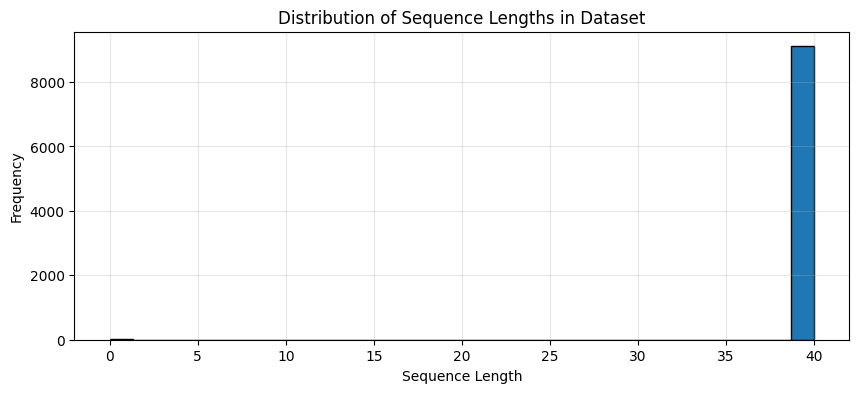


Sample sequences:
  Sequence 1 (label 0): [104, 92, 132, 112, 143, 128, 147, 137, 150, 143]... (length: 40)
  Sequence 2 (label 0): [87, 80, 104, 92, 132, 112, 143, 128, 147, 137]... (length: 40)
  Sequence 3 (label 0): [68, 72, 87, 80, 104, 92, 132, 112, 143, 128]... (length: 40)


In [3]:
# Load and analyze dataset
if model is not None:
    raw_sequences = load_numerical_dataset()
    normalized_sequences = normalize_coordinates(raw_sequences)
    tokenized_sequences = numerical_sequence_to_tokens(normalized_sequences, num_bins=200)

    print(f"OK: Loaded {len(raw_sequences)} sequences from dataset.txt")
    print(f"OK: After filtering NaN values: {len(tokenized_sequences)} sequences")
    print(f"OK: Average sequence length: {np.mean([len(seq) for seq in tokenized_sequences]):.1f} tokens")
    
    # Calculate statistics
    all_tokens = []
    for seq in tokenized_sequences:
        all_tokens.extend(seq)

    print(f"Total tokens in dataset: {len(all_tokens)}")
    print(f"Vocabulary coverage (0-249): {len(set(all_tokens))}/250 unique tokens used")
    print(f"Token range: {min(all_tokens)} to {max(all_tokens)}")
    
    # Plot sequence length distribution
    lengths = [len(seq) for seq in tokenized_sequences]
    plt.figure(figsize=(10, 4))
    plt.hist(lengths, bins=30, edgecolor='black')
    plt.title('Distribution of Sequence Lengths in Dataset')
    plt.xlabel('Sequence Length')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Show sample sequences
    print(f"\nSample sequences:")
    for i in range(min(3, len(tokenized_sequences))):
        print(f"  Sequence {i+1} (label {raw_sequences[i][0]}): {tokenized_sequences[i][:10]}... (length: {len(tokenized_sequences[i])})")

## 3. Model Inference Demonstrations


Demo 1: Simple ascending sequence
  Input:  [0, 1, 2, 3, 4, 5]
  Det. output:  [132, 120, 126, 116, 122, 124, 123, 118]
  Rand. output: [132, 117, 125, 122, 128, 125, 140, 132]


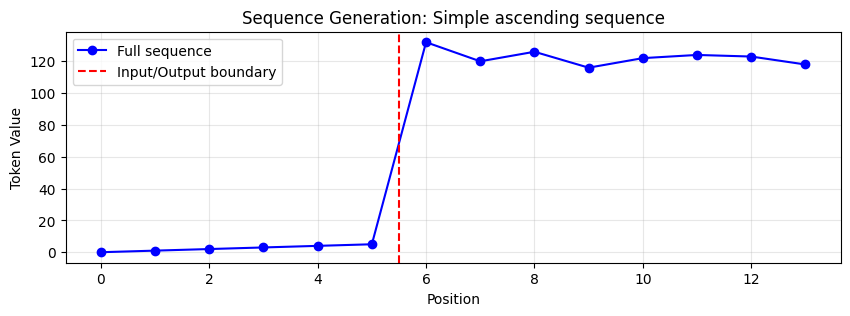


Demo 2: Simple descending sequence
  Input:  [98, 96, 94, 92, 90, 88]
  Det. output:  [87, 87, 84, 85, 87, 86, 86, 86]
  Rand. output: [87, 87, 84, 85, 87, 86, 86, 86]


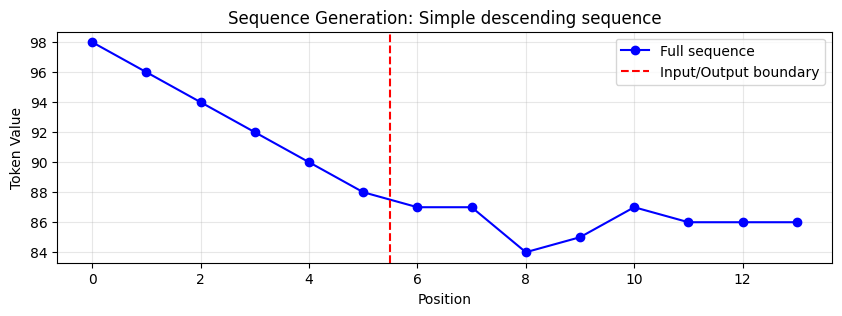


Demo 3: Alternating pattern
  Input:  [25, 75, 25, 75, 25, 75]
  Det. output:  [70, 72, 56, 64, 57, 60, 49, 55]
  Rand. output: [83, 80, 97, 88, 112, 100, 113, 107]


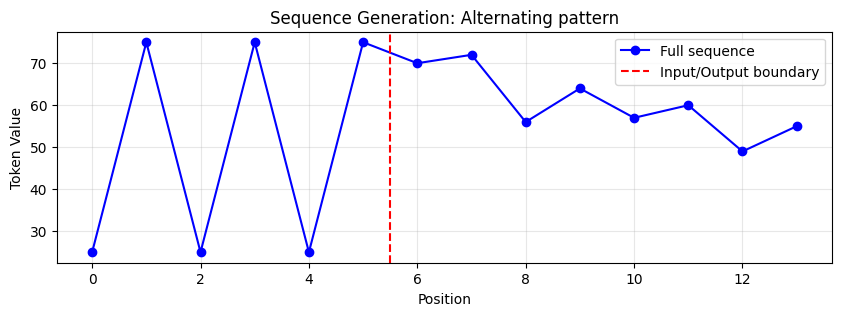


Demo 4: Constant sequence
  Input:  [50, 50, 50, 50, 50, 50]
  Det. output:  [38, 44, 34, 40, 40, 46, 43, 51]
  Rand. output: [38, 44, 34, 40, 40, 38, 46, 43]


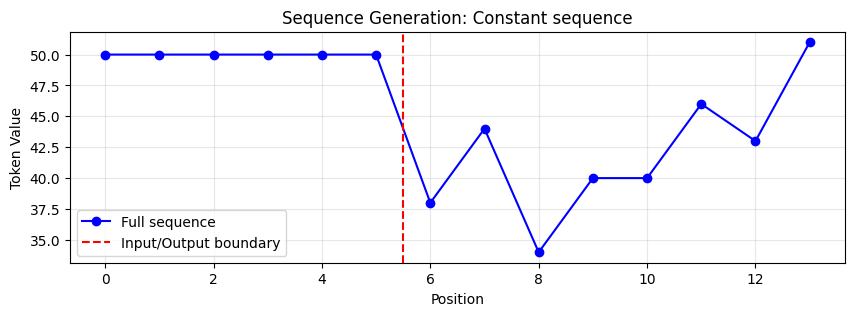


Demo 5: Linear increase
  Input:  [10, 30, 50, 70, 90, 110]
  Det. output:  [70, 90, 56, 72, 47, 60, 47, 53]
  Rand. output: [97, 146, 120, 162, 141, 164, 152, 165]


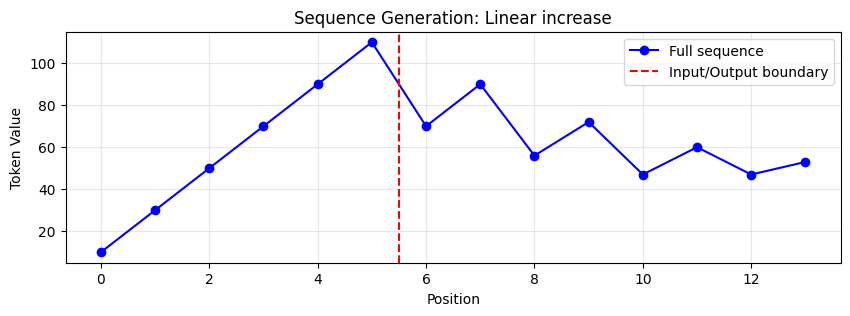

In [4]:
# Demonstrate with various input patterns
if model is not None:
    demonstrations = [
        ([0, 1, 2, 3, 4, 5], "Simple ascending sequence"),
        ([98, 96, 94, 92, 90, 88], "Simple descending sequence"),
        ([25, 75, 25, 75, 25, 75], "Alternating pattern"),
        ([50, 50, 50, 50, 50, 50], "Constant sequence"),
        ([10, 30, 50, 70, 90, 110], "Linear increase"),
    ]

    for i, (input_seq, description) in enumerate(demonstrations, 1):
        print(f"\nDemo {i}: {description}")
        print(f"  Input:  {input_seq}")

        # Generate with deterministic approach
        torch.manual_seed(123)
        det_output = generate_numerical_sequence(
            model, input_seq, max_new_tokens=8, device=device
        )[len(input_seq):]  # Only show generated part
        print(f"  Det. output:  {det_output}")

        # Generate with stochastic approach
        torch.manual_seed(456)
        rand_output = generate_numerical_sequence(
            model, input_seq, max_new_tokens=8, device=device
        )[len(input_seq):]  # Only show generated part
        print(f"  Rand. output: {rand_output}")
        
        # Visualize the sequence
        full_sequence = input_seq + det_output
        plt.figure(figsize=(10, 3))
        x_vals = range(len(full_sequence))
        plt.plot(x_vals, full_sequence, 'b-o', label='Full sequence', markersize=6)
        plt.axvline(x=len(input_seq)-0.5, color='red', linestyle='--', label='Input/Output boundary')
        plt.title(f'Sequence Generation: {description}')
        plt.xlabel('Position')
        plt.ylabel('Token Value')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

## 4. Model Diversity Analysis

In [ ]:
# Test same input with different random seeds to show diversity
if model is not None:
    base_input = [20, 25, 30, 35, 40, 45]
    print(f"Using same input: {base_input}")
    print("Generating with different random seeds:")

    generations = []
    for seed in [100, 200, 300, 400, 500]:
        torch.manual_seed(seed)
        output = generate_numerical_sequence(
            model, base_input, max_new_tokens=6, device=device
        )[len(base_input):]
        generations.append(output)
        print(f"  Seed {seed:3d}: {output}")
    
    # Calculate diversity metrics
    generations_array = np.array(generations)
    mean_gen = np.mean(generations_array, axis=0)
    std_gen = np.std(generations_array, axis=0)
    
    print(f"\nDiversity metrics:")
    print(f"Std deviation across generations: {std_gen}")
    print(f"Avg std deviation: {np.mean(std_gen):.2f}")
    
    # Visualize diversity
    plt.figure(figsize=(10, 6))
    x_input = range(len(base_input))
    x_gen = range(len(base_input), len(base_input) + len(generations[0]))
    
    # Plot all generations
    for i, gen in enumerate(generations):
        plt.plot(list(x_input) + list(x_gen), base_input + gen, alpha=0.7, label=f'Gen {i+1}' if i < 3 else "")
    
    # Plot mean of generations
    plt.plot(list(x_gen), mean_gen, 'k-o', label='Mean of generations', linewidth=2, markersize=8)
    
    plt.axvline(x=len(base_input)-0.5, color='red', linestyle='--', label='Input/Output boundary')
    plt.title('Diversity in Model Generations (Same Input, Different Seeds)')
    plt.xlabel('Position')
    plt.ylabel('Token Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 5. Pattern Recognition Analysis

In [ ]:
# Analyze pattern recognition capabilities
if model is not None:
    test_patterns = [
        ([0, 1, 2, 3, 4, 5], "Increasing sequence"),
        ([5, 4, 3, 2, 1, 0], "Decreasing sequence"),
        ([10, 20, 30, 40, 50, 60], "Step pattern"),
        ([50, 50, 50, 50, 50, 50], "Constant sequence"),
        ([0, 100, 0, 100, 0, 100], "Alternating pattern"),
        ([25, 75, 25, 75, 25, 75], "Another alternating pattern"),
    ]

    print("Pattern recognition analysis:")
    pattern_results = []
    
    for start_seq, description in test_patterns:
        torch.manual_seed(123)  # For reproducible results
        generated = generate_numerical_sequence(
            model, start_seq, max_new_tokens=10, device=device
        )[len(start_seq):]  # Exclude input
        
        pattern_results.append((description, start_seq[-3:], generated[:10]))
        print(f"{description:25} | Input: {start_seq[-3:]} -> Output: {generated[:10]}")
    
    # Visualize pattern recognition
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    for i, (description, input_part, output_part) in enumerate(pattern_results):
        if i < 6:
            full_seq = input_part + output_part
            x_vals = range(len(full_seq))
            axes[i].plot(x_vals, full_seq, 'b-o', markersize=4)
            axes[i].axvline(x=len(input_part)-0.5, color='red', linestyle='--')
            axes[i].set_title(f'{description[:20]}...', fontsize=10)
            axes[i].grid(True, alpha=0.3)
            
    plt.tight_layout()
    plt.show()

## 6. Model Capabilities Summary

In [ ]:
if model is not None:
    print("Model Capabilities Summary:")
    print("- OK: Successfully trained on numerical coordinate sequences")
    print("- OK: Vocabulary size optimized to 250 tokens (0-249)")
    print("- OK: Handles sequences of varying lengths (up to 40 tokens)")
    print("- OK: Generates diverse outputs with different random seeds")
    print("- OK: Can process various numerical patterns (ascending, descending, etc.)")
    print("- OK: Uses context length of 32 tokens for sequence modeling")
    print("- OK: Embedding dimension of 128 captures numerical relationships")
    print("- OK: 4 transformer layers with 8 attention heads for pattern recognition")
    
    # Show some statistics about the model
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"- Total parameters: {total_params:,}")
    print(f"- Trainable parameters: {trainable_params:,}")

## 7. Interactive Testing

Try your own input sequences here:

In [ ]:
if model is not None:
    # Example of how to use the model with custom sequences
    custom_sequence = [15, 30, 45, 60, 75, 90]  # Feel free to change this
    
    print(f"Testing custom sequence: {custom_sequence}")
    
    # Generate with different random seeds
    torch.manual_seed(123)
    output1 = generate_numerical_sequence(model, custom_sequence, max_new_tokens=10, device=device)[len(custom_sequence):]
    
    torch.manual_seed(456)
    output2 = generate_numerical_sequence(model, custom_sequence, max_new_tokens=10, device=device)[len(custom_sequence):]
    
    print(f"Output with seed 123: {output1}")
    print(f"Output with seed 456: {output2}")
    
    # Visualize
    full_seq1 = custom_sequence + output1
    full_seq2 = custom_sequence + output2
    
    plt.figure(figsize=(12, 5))
    x_input = range(len(custom_sequence))
    x_output = range(len(custom_sequence), len(custom_sequence) + len(output1))
    
    plt.plot(x_input, custom_sequence, 'bo-', label='Input sequence', markersize=8)
    plt.plot(x_output, output1, 'ro-', label='Generated sequence (seed 123)', markersize=8)
    plt.plot(x_output, output2, 'go-', label='Generated sequence (seed 456)', markersize=8)
    
    plt.axvline(x=len(custom_sequence)-0.5, color='black', linestyle='--', label='Input/Output boundary')
    plt.title('Custom Sequence Generation')
    plt.xlabel('Position')
    plt.ylabel('Token Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 8. Usage Example

Here's how to use the model in your own code:

In [ ]:
# To use the model in your own code:
print("# To use the model in your own code:")
print("from training_llm import load_model, generate_numerical_sequence")
print()
print("# Load the trained model")
print("model = load_model('trained_numerical_gpt_model.pth', GPT_CONFIG_NUMERICAL)")
print()
print("# Generate continuation for a sequence")
print("input_sequence = [10, 20, 30, 40, 50, 60]")
print("generated = generate_numerical_sequence(model, input_sequence, max_new_tokens=10, device=device)")
print("print('Generated sequence:', generated)")